# Extracción de data


In [1]:
"""
QUERY TAP COMPLETO - 93 COLUMNAS DEL NOTEBOOK KEPLER ORIGINAL
==============================================================
Incluye las 90 features + kepid + kepoi_name + koi_disposition
"""

import pandas as pd
import urllib.parse
import numpy as np

print("=" * 80)
print("DESCARGANDO DATASET COMPLETO - 93 COLUMNAS (NOTEBOOK KEPLER)")
print("=" * 80)

# ==========================================
# QUERY CON LAS 93 COLUMNAS EXACTAS
# ==========================================
query = """
SELECT
    kepid,
    kepoi_name,
    koi_disposition,
    koi_period,
    koi_time0bk,
    koi_time0,
    koi_impact,
    koi_duration,
    koi_depth,
    koi_ror,
    koi_srho,
    koi_fittype,
    koi_prad,
    koi_sma,
    koi_incl,
    koi_teq,
    koi_insol,
    koi_dor,
    koi_ldm_coeff1,
    koi_ldm_coeff2,
    koi_parm_prov,
    koi_period_err1,
    koi_period_err2,
    koi_time0bk_err1,
    koi_time0bk_err2,
    koi_impact_err1,
    koi_impact_err2,
    koi_duration_err1,
    koi_duration_err2,
    koi_depth_err1,
    koi_depth_err2,
    koi_ror_err1,
    koi_ror_err2,
    koi_srho_err1,
    koi_srho_err2,
    koi_prad_err1,
    koi_prad_err2,
    koi_dor_err1,
    koi_dor_err2,
    koi_max_sngle_ev,
    koi_max_mult_ev,
    koi_model_snr,
    koi_count,
    koi_num_transits,
    koi_steff,
    koi_slogg,
    koi_smet,
    koi_srad,
    koi_smass,
    koi_sparprov,
    koi_steff_err1,
    koi_steff_err2,
    koi_slogg_err1,
    koi_slogg_err2,
    koi_smet_err1,
    koi_smet_err2,
    koi_srad_err1,
    koi_srad_err2,
    koi_smass_err1,
    koi_smass_err2,
    ra,
    dec,
    koi_kepmag,
    koi_gmag,
    koi_rmag,
    koi_imag,
    koi_zmag,
    koi_jmag,
    koi_hmag,
    koi_kmag,
    ra_err,
    dec_err,
    koi_kepmag_err,
    koi_gmag_err,
    koi_rmag_err,
    koi_imag_err,
    koi_zmag_err,
    koi_jmag_err,
    koi_hmag_err,
    koi_kmag_err,
    koi_fwm_sra,
    koi_fwm_sdec,
    koi_fwm_srao,
    koi_fwm_sdeco,
    koi_fwm_prao,
    koi_fwm_pdeco,
    koi_fwm_stat_sig,
    koi_dicco_mra,
    koi_dicco_mdec,
    koi_dicco_msky,
    koi_dikco_mra,
    koi_dikco_mdec,
    koi_dikco_msky
FROM cumulative
"""

print("\n📋 Columnas solicitadas: 93")
print("   • 90 features")
print("   • 1 target (koi_disposition)")
print("   • 2 identificadores (kepid, kepoi_name)")

# Codificar URL
query_encoded = urllib.parse.quote(query)
base_url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query="
full_url = f"{base_url}{query_encoded}&format=csv"

print("\n🌐 Descargando datos de NASA Exoplanet Archive...")

# Descargar
try:
    df = pd.read_csv(full_url)
    print(f"✓ Descarga exitosa!")
    print(f"  • Filas: {df.shape[0]:,}")
    print(f"  • Columnas: {df.shape[1]}")

    # Verificar columnas recibidas
    expected_cols = 93
    actual_cols = df.shape[1]

    if actual_cols == expected_cols:
        print(f"\n✅ PERFECTO: Todas las {expected_cols} columnas descargadas")
    else:
        print(f"\n⚠️  Columnas esperadas: {expected_cols}, recibidas: {actual_cols}")
        print(f"    Diferencia: {expected_cols - actual_cols} columnas")

        # Mostrar columnas faltantes si es necesario
        query_cols = [
            'kepid', 'kepoi_name', 'koi_disposition', 'koi_period', 'koi_time0bk',
            'koi_time0', 'koi_impact', 'koi_duration', 'koi_depth', 'koi_ror',
            'koi_srho', 'koi_fittype', 'koi_prad', 'koi_sma', 'koi_incl',
            'koi_teq', 'koi_insol', 'koi_dor', 'koi_ldm_coeff1', 'koi_ldm_coeff2',
            'koi_parm_prov', 'koi_period_err1', 'koi_period_err2', 'koi_time0bk_err1',
            'koi_time0bk_err2', 'koi_impact_err1', 'koi_impact_err2', 'koi_duration_err1',
            'koi_duration_err2', 'koi_depth_err1', 'koi_depth_err2', 'koi_ror_err1',
            'koi_ror_err2', 'koi_srho_err1', 'koi_srho_err2', 'koi_prad_err1',
            'koi_prad_err2', 'koi_dor_err1', 'koi_dor_err2', 'koi_max_sngle_ev',
            'koi_max_mult_ev', 'koi_model_snr', 'koi_count', 'koi_num_transits',
            'koi_steff', 'koi_slogg', 'koi_smet', 'koi_srad', 'koi_smass',
            'koi_sparprov', 'koi_steff_err1', 'koi_steff_err2', 'koi_slogg_err1',
            'koi_slogg_err2', 'koi_smet_err1', 'koi_smet_err2', 'koi_srad_err1',
            'koi_srad_err2', 'koi_smass_err1', 'koi_smass_err2', 'ra', 'dec',
            'koi_kepmag', 'koi_gmag', 'koi_rmag', 'koi_imag', 'koi_zmag',
            'koi_jmag', 'koi_hmag', 'koi_kmag', 'ra_err', 'dec_err',
            'koi_kepmag_err', 'koi_gmag_err', 'koi_rmag_err', 'koi_imag_err',
            'koi_zmag_err', 'koi_jmag_err', 'koi_hmag_err', 'koi_kmag_err',
            'koi_fwm_sra', 'koi_fwm_sdec', 'koi_fwm_srao', 'koi_fwm_sdeco',
            'koi_fwm_prao', 'koi_fwm_pdeco', 'koi_fwm_stat_sig', 'koi_dicco_mra',
            'koi_dicco_mdec', 'koi_dicco_msky', 'koi_dikco_mra', 'koi_dikco_mdec',
            'koi_dikco_msky'
        ]

        missing = set(query_cols) - set(df.columns)
        if missing:
            print(f"\n    Columnas faltantes:")
            for col in sorted(missing):
                print(f"      - {col}")

    # ==========================================
    # ANÁLISIS DE VALORES NULOS
    # ==========================================
    print("\n" + "=" * 80)
    print("ANÁLISIS DE VALORES NULOS")
    print("=" * 80)

    null_counts = df.isnull().sum()
    total_nulls = null_counts.sum()
    total_cells = df.shape[0] * df.shape[1]
    null_percentage = (total_nulls / total_cells) * 100

    print(f"\nTotal de valores nulos: {total_nulls:,} ({null_percentage:.2f}% del dataset)")

    # Top 10 columnas con más nulos
    top_nulls = null_counts.sort_values(ascending=False).head(10)
    if top_nulls.iloc[0] > 0:
        print("\nTop 10 columnas con más valores nulos:")
        for col, count in top_nulls.items():
            pct = (count / len(df)) * 100
            print(f"  • {col:25s}: {count:5,} ({pct:5.1f}%)")

    # ==========================================
    # PREPARAR DATOS COMO EL NOTEBOOK ORIGINAL
    # ==========================================
    print("\n" + "=" * 80)
    print("PREPARACIÓN DE DATOS (ESTILO NOTEBOOK KEPLER)")
    print("=" * 80)

    # Lista de columnas a eliminar (IGUAL que el notebook)
    cols_to_drop_desired = [
        'rowid', 'kepid', 'kepoi_name', 'kepler_name', 'koi_vet_stat', 'koi_vet_date',
        'koi_pdisposition', 'koi_score', 'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co',
        'koi_fpflag_ec', 'koi_disp_prov', 'koi_comment', 'koi_eccen', 'koi_eccen_err1',
        'koi_eccen_err2', 'koi_longp', 'koi_longp_err1', 'koi_longp_err2', 'koi_ingress',
        'koi_ingress_err1', 'koi_ingress_err2', 'koi_sma_err1', 'koi_sma_err2', 'koi_incl_err1',
        'koi_incl_err2', 'koi_teq_err1', 'koi_teq_err2', 'koi_limbdark_mod', 'koi_ldm_coeff4',
        'koi_ldm_coeff3', 'koi_tce_plnt_num', 'koi_tce_delivname', 'koi_quarters',
        'koi_bin_oedp_sig', 'koi_trans_mod', 'koi_model_dof', 'koi_model_chisq',
        'koi_datalink_dvr', 'koi_datalink_dvs', 'koi_sage', 'koi_sage_err1', 'koi_sage_err2'
    ]

    # Filtrar solo las columnas que existen
    cols_to_drop = [col for col in cols_to_drop_desired if col in df.columns]

    print(f"\n✓ Columnas a eliminar: {len(cols_to_drop)} de {len(cols_to_drop_desired)} deseadas")

    # Eliminar columnas
    df_processed = df.drop(columns=cols_to_drop).reset_index(drop=True)

    print(f"✓ Dataset después de eliminar columnas: {df_processed.shape}")

    # Preparar target
    Y = df_processed['koi_disposition'].map({'FALSE POSITIVE': 0, 'CONFIRMED': 1})

    # Preparar features
    X = df_processed.drop(columns=['koi_disposition'])
    X_filled = X.fillna(0)

    print(f"\n✓ Target (Y) preparado:")
    print(f"  • Shape: {Y.shape}")
    print(f"  • FALSE POSITIVE (0): {(Y==0).sum():,}")
    print(f"  • CONFIRMED (1): {(Y==1).sum():,}")
    print(f"  • Valores nulos: {Y.isnull().sum()}")

    print(f"\n✓ Features (X) preparadas:")
    print(f"  • Shape antes de encoding: {X_filled.shape}")

    # Aplicar one-hot encoding a columnas categóricas
    categorical_cols = X_filled.select_dtypes(include=['object']).columns.tolist()
    if categorical_cols:
        print(f"\n📝 Columnas categóricas detectadas: {len(categorical_cols)}")
        for col in categorical_cols:
            unique_vals = X_filled[col].nunique()
            print(f"  • {col}: {unique_vals} valores únicos")

        X_encoded = pd.get_dummies(X_filled, drop_first=False).astype(np.float32)
        print(f"\n✓ One-hot encoding aplicado")
        print(f"  • Shape después de encoding: {X_encoded.shape}")
    else:
        X_encoded = X_filled.astype(np.float32)
        print(f"\n✓ No hay columnas categóricas")

    # Filtrar por target válido
    mask = Y.notna()
    X_final = X_encoded[mask]
    Y_final = Y[mask].astype(np.float32)

    print(f"\n✓ Datos finales (después de filtrar nulos en target):")
    print(f"  • X: {X_final.shape}")
    print(f"  • Y: {Y_final.shape}")

    # ==========================================
    # GUARDAR ARCHIVOS
    # ==========================================
    print("\n" + "=" * 80)
    print("GUARDANDO ARCHIVOS")
    print("=" * 80)

    # Guardar dataset completo
    filename_complete = 'kepler_db_complete_93cols.csv'
    df.to_csv(filename_complete, index=False)
    print(f"\n✓ Dataset completo guardado: {filename_complete}")
    print(f"  • {df.shape[0]:,} filas × {df.shape[1]} columnas")

    # Guardar dataset procesado (sin columnas eliminadas)
    filename_processed = 'kepler_db_processed.csv'
    df_processed.to_csv(filename_processed, index=False)
    print(f"\n✓ Dataset procesado guardado: {filename_processed}")
    print(f"  • {df_processed.shape[0]:,} filas × {df_processed.shape[1]} columnas")
    print(f"  • Sin columnas eliminadas por el notebook")

    # ==========================================
    # RESUMEN FINAL
    # ==========================================
    print("\n" + "=" * 80)
    print("✅ RESUMEN FINAL")
    print("=" * 80)

    print(f"""
Archivos generados:
  1. {filename_complete}
     • Dataset RAW con todas las {df.shape[1]} columnas descargadas
     • Usar para análisis exploratorio

  2. {filename_processed}
     • Dataset PROCESADO listo para entrenar
     • {df_processed.shape[1]} columnas (después de drops)
     • Incluye koi_disposition como target

Próximos pasos para entrenar:
  1. df = pd.read_csv('{filename_processed}')
  2. Y = df['koi_disposition'].map({{'FALSE POSITIVE': 0, 'CONFIRMED': 1}})
  3. X = df.drop(columns=['koi_disposition']).fillna(0)
  4. X_encoded = pd.get_dummies(X, drop_first=False)
  5. Entrenar modelo con X_encoded, Y

Columnas finales para features: {X_final.shape[1]} (después de one-hot encoding)
    """)

    print("=" * 80)
    print("🎉 ¡DATASET LISTO PARA USAR!")
    print("=" * 80)

except Exception as e:
    print(f"\n❌ ERROR al descargar datos:")
    print(f"   {type(e).__name__}: {e}")
    print("\nPosibles causas:")
    print("  • Problemas de red")
    print("  • API de NASA temporalmente no disponible")
    print("  • Alguna columna no existe en la tabla cumulative")

DESCARGANDO DATASET COMPLETO - 93 COLUMNAS (NOTEBOOK KEPLER)

📋 Columnas solicitadas: 93
   • 90 features
   • 1 target (koi_disposition)
   • 2 identificadores (kepid, kepoi_name)

🌐 Descargando datos de NASA Exoplanet Archive...
✓ Descarga exitosa!
  • Filas: 9,564
  • Columnas: 93

✅ PERFECTO: Todas las 93 columnas descargadas

ANÁLISIS DE VALORES NULOS

Total de valores nulos: 79,565 (8.95% del dataset)

Top 10 columnas con más valores nulos:
  • koi_gmag_err             : 9,564 (100.0%)
  • koi_kepmag_err           : 9,564 (100.0%)
  • koi_rmag_err             : 9,564 (100.0%)
  • koi_imag_err             : 9,564 (100.0%)
  • koi_zmag_err             : 9,564 (100.0%)
  • koi_num_transits         : 1,142 ( 11.9%)
  • koi_max_mult_ev          : 1,142 ( 11.9%)
  • koi_max_sngle_ev         : 1,142 ( 11.9%)
  • koi_fwm_stat_sig         : 1,076 ( 11.3%)
  • koi_fwm_prao             :   830 (  8.7%)

PREPARACIÓN DE DATOS (ESTILO NOTEBOOK KEPLER)

✓ Columnas a eliminar: 2 de 44 deseadas
✓

In [2]:
from sklearn.model_selection import train_test_split
import pandas as pd

# ==========================================
# 1. DEFINIR COLUMNAS REDUNDANTES A ELIMINAR
# ==========================================
# Lista exacta que encontró tu análisis
cols_redundantes = [
    'koi_time0', 'koi_ror', 'koi_dor',
    'koi_period_err2', 'koi_time0bk_err2', 'koi_duration_err2',
    'koi_depth_err2', 'koi_ror_err1', 'koi_ror_err2',
    'koi_prad_err2', 'koi_dor_err1', 'koi_dor_err2',
    'koi_rmag', 'koi_hmag', 'koi_kmag'
]

print(f"✂️ Eliminando {len(cols_redundantes)} columnas redundantes...")

# ==========================================
# 2. RECARGAR Y LIMPIAR DATASET
# ==========================================
# Cargamos de nuevo el procesado original
df = pd.read_csv('kepler_db_processed.csv')

# Preparamos Target
y = df['koi_disposition'].map({'FALSE POSITIVE': 0, 'CONFIRMED': 1, 'CANDIDATE': 1})

# Preparamos Features (Quitando las redundantes)
X = df.drop(columns=['koi_disposition'])

# ¡AQUÍ ESTÁ LA MAGIA! Borramos las columnas gemelas
# Usamos errors='ignore' por si alguna ya no estaba (ej. si corres esto dos veces)
X = X.drop(columns=cols_redundantes, errors='ignore')

# Limpieza estándar (Nulos y Encoding)
X = X.fillna(0)
X = pd.get_dummies(X, drop_first=True)

# Split (Misma semilla para comparar manzanas con manzanas)
X_train_light, X_test_light, y_train_light, y_test_light = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Nuevo X_train (Ligero): {X_train_light.shape}")
print(f"   (Bajamos de 93 a {X_train_light.shape[1]} columnas)")


✂️ Eliminando 15 columnas redundantes...
✅ Nuevo X_train (Ligero): (7651, 81)
   (Bajamos de 93 a 81 columnas)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Preparado para entrenar con X_train: {X_train.shape}")

✅ Preparado para entrenar con X_train: (7651, 81)


# Modelo

In [4]:
# ESTE SI

import pandas as pd
import numpy as np
import random
import os

# Scikit-Learn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# ==========================================
# 1. CONFIGURACIÓN DE SEMILLAS (ALEATORIZACIÓN CONTROLADA)
# ==========================================
def set_global_seed(seed=42):
    """
    Fija todas las semillas aleatorias para que el experimento sea reproducible.
    Esto es crucial para comparar modelos científicamente.
    """
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    print(f"🔒 Semilla global fijada en: {seed}")

set_global_seed(42) # Puedes cambiar este número, pero manténlo fijo durante las pruebas

# ==========================================
# 2. DEFINICIÓN DEL MODELO ROBUSTO
# ==========================================
def build_robust_mlp(meta):
    n_features_in_ = meta["n_features_in_"]

    # REGLA: "Entre más regularización, puedo aumentar la complejidad"
    # Iniciamos con muchas neuronas para captar patrones sutiles.

    model = keras.Sequential([
        keras.Input(shape=(n_features_in_,)),

        # --- CAPA 1: Entrada y Alta Complejidad ---
        # REGLA: "No usar dropout en la primera capa"
        # Queremos que la red vea toda la información original sin ruido.
        layers.Dense(512),
        layers.BatchNormalization(), # Estabiliza el aprendizaje (ayuda al backpropagation)
        layers.Activation('relu'),
        # NO DROPOUT AQUÍ

        # --- CAPA 2: Reducción Suave ---
        # REGLA: "Reducciones no drásticas" (512 -> 256 es suave)
        # REGLA: "Empezar dropout mínimo" (0.3)
        layers.Dense(256),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3), # 30% de neuronas se apagan aleatoriamente

        # --- CAPA 3: Compresión ---
        # REGLA: "Aumentar dropout secuencialmente" (0.3 -> 0.4)
        layers.Dense(128),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.4), # 40% dropout


        # --- CAPA 4: Refinamiento Final ---
        # REGLA: "Dropout máximo" (0.5)
        layers.Dense(64),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5), # 50% dropout (muy agresivo, fuerza a aprender características robustas)

        # --- SALIDA ---
        layers.Dense(1, activation='sigmoid')
    ])

    # CONFIGURACIÓN DEL BACKPROPAGATION
    # Usamos Adam, que gestiona el gradiente descendente de forma adaptativa.
    optimizer = keras.optimizers.Adam(learning_rate=0.001)

    model.compile(
        loss='binary_crossentropy',
        optimizer=optimizer,
        metrics=[
            'accuracy',
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall')
        ]
    )

    return model

# ==========================================
# 3. WRAPPER (Igual que antes, necesario para Pipeline)
# ==========================================
class KerasClassifierWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, build_fn, epochs=100, batch_size=32, verbose=0, callbacks=None):
        self.build_fn = build_fn
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.callbacks = callbacks
        self.model_ = None

    def fit(self, X, y):
        self.n_features_in_ = X.shape[1]
        meta = {"n_features_in_": self.n_features_in_}
        self.model_ = self.build_fn(meta)

        # REGLA: "Conjunto de validación"
        # validation_split=0.2 separa automáticamente el 20% para validar
        self.model_.fit(
            X, y,
            epochs=self.epochs,
            batch_size=self.batch_size,
            verbose=self.verbose,
            validation_split=0.2,
            callbacks=self.callbacks if self.callbacks else []
        )
        return self

    def predict(self, X):
        return (self.model_.predict(X, verbose=0) > 0.5).astype(int).flatten()

    def predict_proba(self, X): # Necesario para curvas ROC/AUC si las usas
        probs = self.model_.predict(X, verbose=0)
        return np.column_stack([1 - probs, probs])

# ==========================================
# 4. EJECUCIÓN CON TUS DATOS
# ==========================================

# Asegúrate de haber cargado y procesado los datos como en el paso anterior
# (Lectura del CSV, map del target, get_dummies, etc.)

# Callbacks para evitar sobreajuste
mis_callbacks = [
    callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

# Pipeline
pipeline_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KerasClassifierWrapper(
        build_fn=build_robust_mlp,
        epochs=100,            # Le damos muchas épocas, el EarlyStopping lo parará si es necesario
        batch_size=64,         # Batch size estándar
        verbose=1,             # Ponlo en 1 para ver el progreso del backpropagation
        callbacks=mis_callbacks
    ))
])

print("\n🧠 Entrenando Modelo Robusto con Dropout Progresivo...")
# Entrenamos (Aquí ocurre el Forward y Back Propagation)
pipeline_mlp.fit(X_train, y_train)

print("\nEvaluando en Test Set...")
from sklearn.metrics import classification_report
y_pred = pipeline_mlp.predict(X_test)
print(classification_report(y_test, y_pred))

🔒 Semilla global fijada en: 42

🧠 Entrenando Modelo Robusto con Dropout Progresivo...
Epoch 1/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.7026 - loss: 0.5749 - precision: 0.6596 - recall: 0.8349 - val_accuracy: 0.8726 - val_loss: 0.3024 - val_precision: 0.8419 - val_recall: 0.9246 - learning_rate: 0.0010
Epoch 2/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8385 - loss: 0.3510 - precision: 0.8388 - recall: 0.8262 - val_accuracy: 0.8726 - val_loss: 0.2965 - val_precision: 0.8349 - val_recall: 0.9361 - learning_rate: 0.0010
Epoch 3/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8603 - loss: 0.3081 - precision: 0.8596 - recall: 0.8517 - val_accuracy: 0.8779 - val_loss: 0.2786 - val_precision: 0.8473 - val_recall: 0.9285 - learning_rate: 0.0010
Epoch 4/100
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8797 - loss: 0.2928 - precision: 0.8773 - recall: 0.8749 - val_accuracy: 0.8831 - val_loss: 0.2722 - val_precision: 0.8587 - val_recall: 0.9234 - 

# Resultados

## MLP propuesto

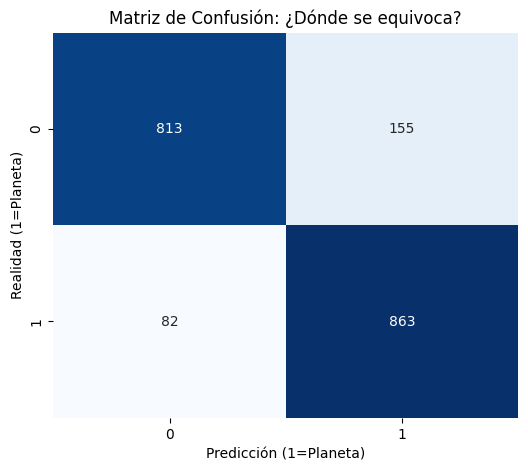


--- Resultados con Umbral Estricto (0.5) ---
              precision    recall  f1-score   support

           0       0.91      0.84      0.87       968
           1       0.85      0.91      0.88       945

    accuracy                           0.88      1913
   macro avg       0.88      0.88      0.88      1913
weighted avg       0.88      0.88      0.88      1913



In [5]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Matriz de Confusión Visual
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicción (1=Planeta)')
plt.ylabel('Realidad (1=Planeta)')
plt.title('Matriz de Confusión: ¿Dónde se equivoca?')
plt.show()

# 2. Análisis de Umbral (Threshold)
# Vamos a ver qué pasa si exigimos un 70% de seguridad en lugar de 50%
y_probs = pipeline_mlp.predict_proba(X_test)[:, 1] # Probabilidad de ser planeta

# Probamos subir la vara a 0.70
nuevo_umbral = 0.50
y_pred_stricter = (y_probs > nuevo_umbral).astype(int)

print(f"\n--- Resultados con Umbral Estricto ({nuevo_umbral}) ---")
print(classification_report(y_test, y_pred_stricter))

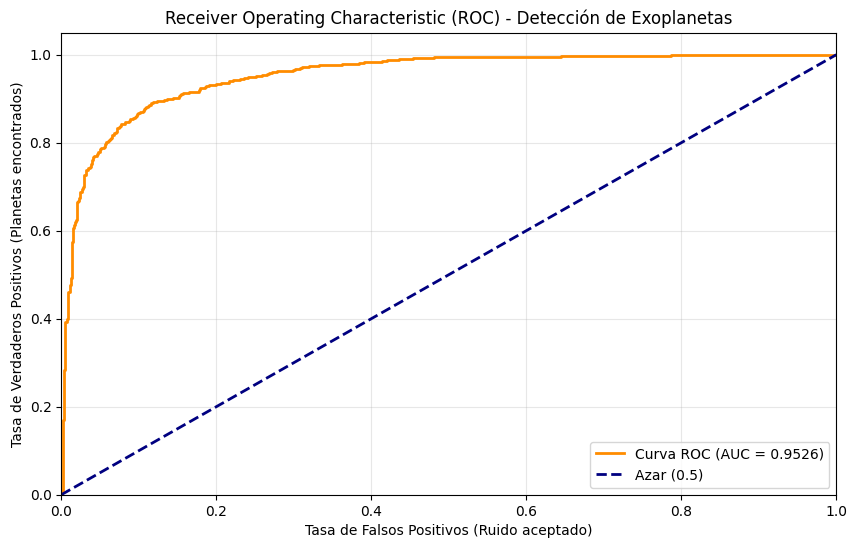

🌟 Tu puntaje AUC es: 0.9526


In [6]:
from sklearn.metrics import roc_curve, auc

# 1. Obtener las probabilidades de que sea "Clase 1" (Planeta)
# Usamos [:, 1] para quedarnos solo con la columna de probabilidad positiva
y_probs = pipeline_mlp.predict_proba(X_test)[:, 1]

# 2. Calcular los puntos de la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# 3. Graficar
plt.figure(figsize=(10, 6))

# La curva del modelo
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')

# La línea de "adivinar al azar" (50/50)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Azar (0.5)')

# Decoración
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (Ruido aceptado)')
plt.ylabel('Tasa de Verdaderos Positivos (Planetas encontrados)')
plt.title('Receiver Operating Characteristic (ROC) - Detección de Exoplanetas')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

print(f"🌟 Tu puntaje AUC es: {roc_auc:.4f}")

## Benchmark

🚀 Iniciando Benchmark de modelos...
Evaluando Random Forest...
Evaluando XGBoost...
Evaluando SVM (RBF)...
Evaluando Logistic Regression...
Evaluando tu MLP (build_robust_mlp)...

             RESULTADOS DEL BENCHMARK


,Modelo,Exactitud,Precisión (Planeta),Recall (Planeta),F1-Score,ROC-AUC
1,XGBoost,0.898589,0.891554,0.904762,0.898109,0.968720
0,Random Forest,0.896498,0.904659,0.883598,0.894004,0.967291
4,Tu MLP (Robusto),0.876111,0.847741,0.913228,0.879266,0.952617
2,SVM (RBF),0.876634,0.867358,0.885714,0.876440,0.950348
3,Logistic Regression,0.868270,0.851064,0.888889,0.869565,0.939035


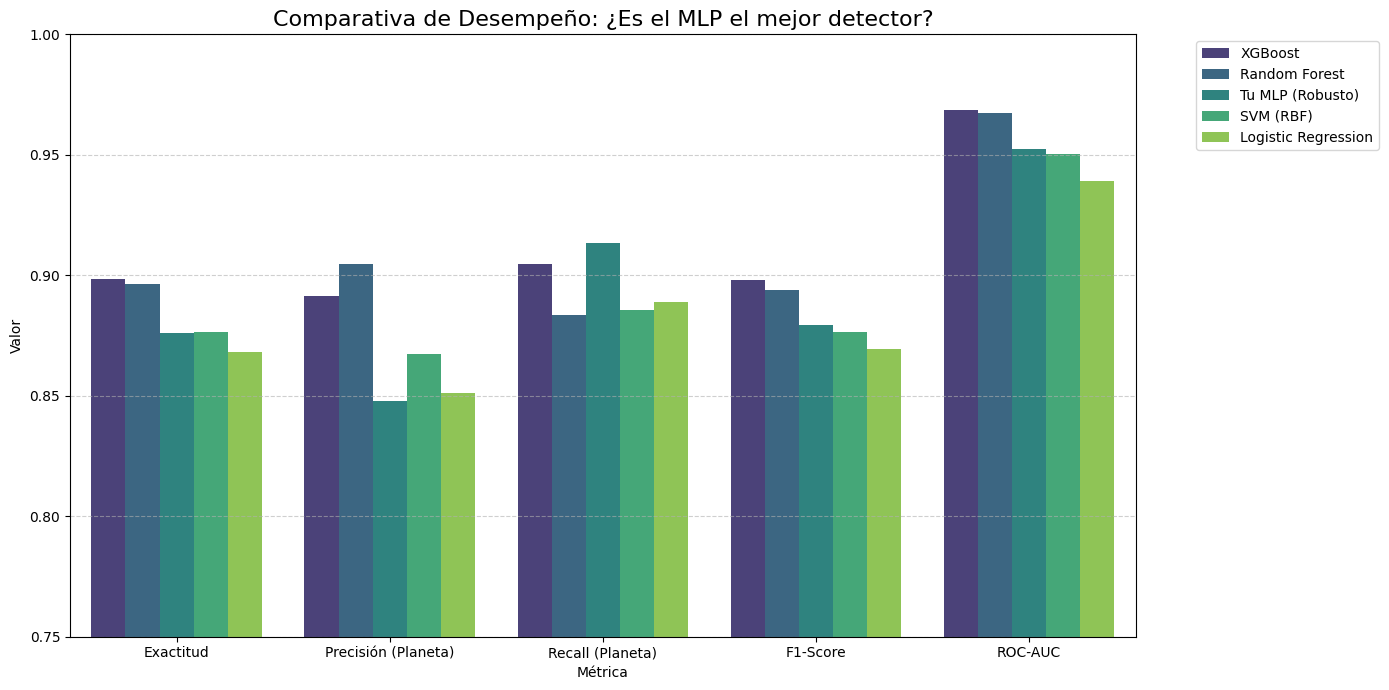

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# ==========================================
# 1. CONFIGURACIÓN DE LOS 4 MODELOS BASE
# ==========================================
# Estos modelos servirán de línea base (baseline) contra tu MLP
modelos_baseline = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42),
    "SVM (RBF)": SVC(kernel='rbf', probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
}

# El MLP ya lo tienes definido como 'pipeline_mlp' en tu notebook
# Lo agregaremos a la lista de evaluación
resultados_benchmark = []

# ==========================================
# 2. EVALUACIÓN DE BASELINES
# ==========================================
print("🚀 Iniciando Benchmark de modelos...")

for nombre, modelo in modelos_baseline.items():
    print(f"Evaluando {nombre}...")
    # Pipeline simple para baselines (Escalado + Modelo)
    # Nota: SVM y LogReg necesitan escalado, RF y XGB no tanto pero no les afecta
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler

    pipe = make_pipeline(StandardScaler(), modelo)
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    resultados_benchmark.append({
        "Modelo": nombre,
        "Exactitud": accuracy_score(y_test, y_pred),
        "Precisión (Planeta)": precision_score(y_test, y_pred),
        "Recall (Planeta)": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

# ==========================================
# 3. EVALUACIÓN DE TU MLP (build_robust_mlp)
# ==========================================
print("Evaluando tu MLP (build_robust_mlp)...")
# Asumimos que 'pipeline_mlp' ya fue entrenado o lo entrenamos aquí
# pipeline_mlp.fit(X_train, y_train) # Descomenta si no lo has entrenado aún

y_pred_mlp = pipeline_mlp.predict(X_test)
y_proba_mlp = pipeline_mlp.predict_proba(X_test)[:, 1]

resultados_benchmark.append({
    "Modelo": "Tu MLP (Robusto)",
    "Exactitud": accuracy_score(y_test, y_pred_mlp),
    "Precisión (Planeta)": precision_score(y_test, y_pred_mlp),
    "Recall (Planeta)": recall_score(y_test, y_pred_mlp),
    "F1-Score": f1_score(y_test, y_pred_mlp),
    "ROC-AUC": roc_auc_score(y_test, y_proba_mlp)
})

# ==========================================
# 4. TABLA COMPARATIVA Y VISUALIZACIÓN
# ==========================================
df_res = pd.DataFrame(resultados_benchmark).sort_values(by="F1-Score", ascending=False)

print("\n" + "="*50)
print("             RESULTADOS DEL BENCHMARK")
print("="*50)
display(df_res)

# Gráfico de barras para comparar métricas clave
df_melt = df_res.melt(id_vars="Modelo", var_name="Métrica", value_name="Valor")
plt.figure(figsize=(14, 7))
sns.barplot(data=df_melt, x="Métrica", y="Valor", hue="Modelo", palette="viridis")
plt.title("Comparativa de Desempeño: ¿Es el MLP el mejor detector?", fontsize=16)
plt.ylim(0.75, 1.0) # Zoom en la zona de interés
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()